<a href="https://colab.research.google.com/github/tmq24/Digital-Image-Analysis-and-Processing/blob/main/Image_Inpainting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import cv2 as cv
import os
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from pylab import imread
import gdown
from google.colab.patches import cv2_imshow
import torch

In [ ]:
gdown.download('https://drive.google.com/uc?export=download&id=1wVWDBlwAmtB-dBA7974_nH1XrolXqjf9', 'caucasian.jpg', quiet=False)
gdown.download('https://drive.google.com/uc?export=download&id=1yLjdbM_gpMvtvCi9mxLtDWIqoaZ1f0nq', 'messi.jpg', quiet=False)
gdown.download('https://drive.google.com/uc?export=download&id=1LXZ8kLjrekl0NDtWpqfjtVfrtTpfa7Sr', 'mask_messi.jpg', quiet=False)

Downloading...
From: https://drive.google.com/uc?export=download&id=1wVWDBlwAmtB-dBA7974_nH1XrolXqjf9
To: /content/caucasian.jpg
100%|██████████| 17.2k/17.2k [00:00<00:00, 28.2MB/s]
Downloading...
From: https://drive.google.com/uc?export=download&id=1yLjdbM_gpMvtvCi9mxLtDWIqoaZ1f0nq
To: /content/messi.jpg
100%|██████████| 67.8k/67.8k [00:00<00:00, 2.95MB/s]
Downloading...
From: https://drive.google.com/uc?export=download&id=1LXZ8kLjrekl0NDtWpqfjtVfrtTpfa7Sr
To: /content/mask_messi.jpg
100%|██████████| 3.44k/3.44k [00:00<00:00, 8.75MB/s]


'mask_messi.jpg'

In [ ]:
fil_path = '/content'  # Base directory path for image files
imgcaucasian = 'caucasian.jpg'  # Filename of the bridge image
imgmessi = 'messi.jpg'  # Filename of the messi image
img_mask_messi = "mask_messi.jpg"

In [ ]:
messi_path = os.path.join(fil_path, imgmessi)
caucasian_path = os.path.join(fil_path, imgcaucasian)
img_mask_messi_path = os.path.join(fil_path, img_mask_messi)

#**Image Inpainting**

Image inpainting is the task of restoring missing or damaged regions of an image using information from the surrounding pixels. Image inpainting has many practical applications, such as restoring old photos, removing unwanted objects, filling in occlusions, and creating realistic image compositions. Machine Learning models can learn to perform image inpainting by training on large datasets of images and learning the patterns and structures of natural images. In this article, we will investigate one of the most popular, state-of-the-art image inpainting models, discuss its core building blocks, and walk through a hands-on example of real-life application in the e-commerce industry.

In [ ]:
def get_pixel_intensity(image_path, i, j):
    """
    Reads a grayscale image using OpenCV and retrieves the intensity
    at the specified pixel coordinates (i, j).

    Args:
        image_path (str): Path to the grayscale image.
        i (int): Row index of the pixel (y-coordinate).
        j (int): Column index of the pixel (x-coordinate).

    Returns:
        int: Pixel intensity (0-255) if the coordinates are valid.
        str: Error message if the coordinates are out of bounds.
    """
    # Read the image in grayscale mode
    image = cv.imread(image_path, cv.IMREAD_GRAYSCALE)

    if image is None:
        return "Image could not be loaded. Please check the file path."

    # Check if (i, j) is within the image bounds
    if 0 <= i < image.shape[0] and 0 <= j < image.shape[1]:
        return image[i, j]  # Return the pixel intensity
    else:
        return "Coordinates are out of bounds."



In [ ]:
def mark_point_on_image(image_path, i, j):
    """
    Marks a black dot at the specified (i, j) coordinate on the grayscale image.

    Args:
        image_path (str): Path to the image file.
        i (int): Row index of the point (y-coordinate).
        j (int): Column index of the point (x-coordinate).

    Returns:
        None: Displays the modified image with the marked point.
    """
    # Load the grayscale image
    image = cv.imread(image_path, cv.IMREAD_GRAYSCALE)

    if image is None:
        print("Error: Unable to load the image. Please check the file path.")
        return

    # Check if (i, j) is within the bounds of the image
    if 0 <= i < image.shape[0] and 0 <= j < image.shape[1]:
        # Mark a black dot (pixel value = 0) at the given coordinate
        image[i, j] = 0
        # Display the image
        plt.imshow(image, cmap='gray')
        plt.scatter([j], [i], c='red', s=10, label=f"Point ({i},{j})")  # Mark the point in red for visibility
        plt.legend()
        plt.title("Image with Marked Point")
        plt.show()
    else:
        print("Error: Coordinates are out of bounds.")

In [ ]:
def inpaint_image(image_path, mask_path, inpaint_radius=3, inpaint_method=cv.INPAINT_TELEA):
    """
    Applies inpainting to an image using a specified mask.

    Parameters:
        image_path (str): Path to the input image.
        mask_path (str): Path to the grayscale mask image.
        inpaint_radius (int): Radius of a circular neighborhood of each point inpainted.
        inpaint_method (int): Inpainting method, either cv.INPAINT_TELEA or cv.INPAINT_NS.

    Returns:
        dst (ndarray): The inpainted image.
    """
    img = cv.imread(image_path)
    # Load the mask image
    mask = cv.imread(mask_path, cv.IMREAD_GRAYSCALE) # Load mask as grayscale

    if img is None:
        raise ValueError(f"Cannot load image from path: {image_path}")

    # Use the loaded mask (NumPy array) in cv.inpaint
    dst = cv.inpaint(img, mask, inpaint_radius, inpaint_method)
    return dst

In [ ]:
def inpaint1_image(image_path, mask, inpaint_radius=3, inpaint_method=cv.INPAINT_TELEA):
    """
    Applies inpainting to an image using a specified mask.

    Parameters:
        image_path (str): Path to the input image.
        mask_path (str): Path to the grayscale mask image.
        inpaint_radius (int): Radius of a circular neighborhood of each point inpainted.
        inpaint_method (int): Inpainting method, either cv.INPAINT_TELEA or cv.INPAINT_NS.

    Returns:
        dst (ndarray): The inpainted image.
    """
    img = cv.imread(image_path)
    # Load the mask image


    if img is None:
        raise ValueError(f"Cannot load image from path: {image_path}")

    # Use the loaded mask (NumPy array) in cv.inpaint
    dst = cv.inpaint(img, mask, inpaint_radius, inpaint_method)
    return dst

In [ ]:
def threshold_image(image, I_lower, I_upper, region):
    """
    Apply a threshold to a specific region of an image.
    Pixels within the range [I_lower, I_upper] will be set to 255, otherwise set to 0.
    Pixels outside the specified region will remain unchanged.

    Args:
        image (numpy.ndarray): Input image as a 2D or 3D array.
        I_lower (float): Lower threshold value.
        I_upper (float): Upper threshold value.
        region (tuple, optional): Coordinates of the region (x_start, y_start, x_end, y_end).
                                  If None, apply to the entire image.

    Returns:
        numpy.ndarray: Image after applying the threshold.
    """
    # Copy the image to avoid modifying the original
    result_image = np.copy(image)

    if region:
        x_start, y_start, x_end, y_end = region
        # Apply the threshold only within the specified region
        result_image[y_start:y_end, x_start:x_end] = np.where(
            (I_lower <= image[y_start:y_end, x_start:x_end]) &
            (image[y_start:y_end, x_start:x_end] <= I_upper),
            255,
            0
        )
        result_image[np.r_[:y_start, y_end:result_image.shape[0]], :] = 0
        result_image[:, np.r_[:x_start, x_end:result_image.shape[1]]] = 0
    else:
        # Apply the threshold to the entire image
        result_image = np.where((I_lower <= image) & (image <= I_upper), 255, 0)

    return result_image


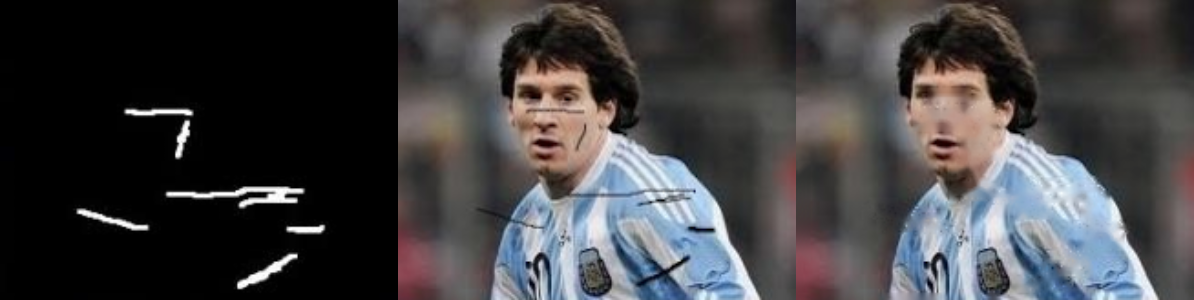

In [ ]:
mask_messi = cv.imread(img_mask_messi_path)
original_messi = cv.imread(messi_path)
inpaint_messi = inpaint_image(messi_path,img_mask_messi_path)

height = 300
mask_messi_resized = cv.resize(mask_messi, (int(mask_messi.shape[1] * height / mask_messi.shape[0]), height))
original_messi_resized = cv.resize(original_messi, (int(original_messi.shape[1] * height / original_messi.shape[0]), height))
inpaint_messi_resized = cv.resize(inpaint_messi, (int(inpaint_messi.shape[1] * height / inpaint_messi.shape[0]), height))


combined_image = np.hstack((mask_messi_resized, original_messi_resized, inpaint_messi_resized))


cv2_imshow(combined_image)

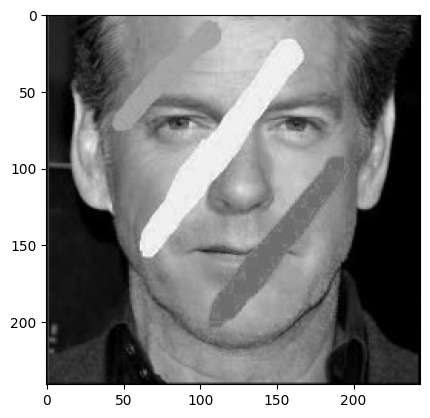

In [ ]:
# Load the grayscale image from 'imgKarlMax_path'
img = cv.imread(caucasian_path, cv.IMREAD_GRAYSCALE)

# Verify that the image has been loaded successfully; if not, raise an error message
assert img is not None, "File could not be read; check with os.path.exists()"
# Display the stacked image
plt.imshow(img, cmap="gray")  # Show 'res' as a grayscale image
plt.show()

45 - > 110

5 - > 69

In [ ]:
img.shape

(241, 244)

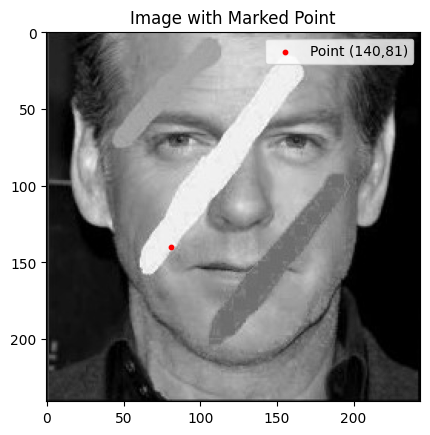

In [ ]:
mark_point_on_image(caucasian_path,140,81)

In [ ]:
I = get_pixel_intensity(caucasian_path,140,82)
print(I)

226


(241, 244)


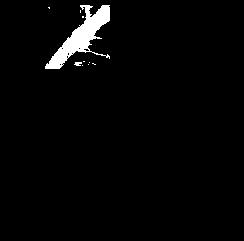

In [ ]:
mask_caucasian = threshold_image(img, 149, 164,(45,5,110,69))
print(mask_caucasian.shape)
mask_caucasian_show = cv2_imshow(mask_caucasian)


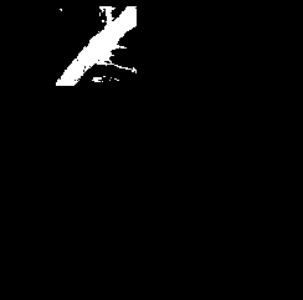

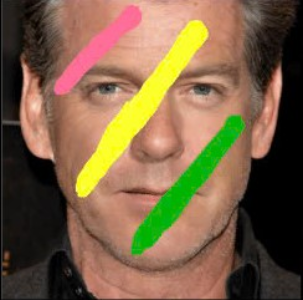

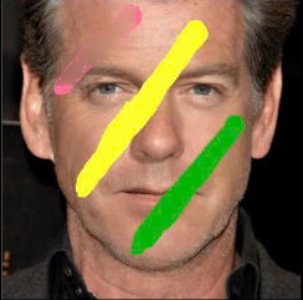

In [ ]:
inpaint_caucasian = inpaint1_image(caucasian_path, mask_caucasian,inpaint_radius=100, inpaint_method=cv.INPAINT_TELEA)
height = 300
original_caucasian = cv.imread(caucasian_path)
# Resize the images
mask_caucasian_resized = cv.resize(mask_caucasian, (int(mask_caucasian.shape[1] * height / mask_caucasian.shape[0]), height))
original_caucasian_resized = cv.resize(original_caucasian, (int(original_caucasian.shape[1] * height / original_caucasian.shape[0]), height))
inpaint_caucasian_resized = cv.resize(inpaint_caucasian, (int(inpaint_caucasian.shape[1] * height / inpaint_caucasian.shape[0]), height))



cv2_imshow(mask_caucasian_resized)
cv2_imshow(original_caucasian_resized)
cv2_imshow(inpaint_caucasian_resized)


#Converting RGB2HSV and HSV2RGB

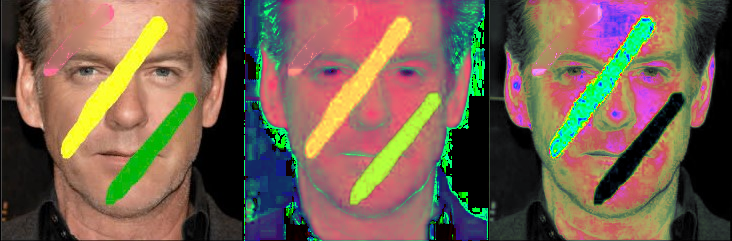

In [ ]:
# Convert RGB to HSV
hsv_image = cv.cvtColor(inpaint_caucasian, cv.COLOR_RGB2HSV)
# Convert HSV back to RGB
rgb_image = cv.cvtColor(inpaint_caucasian, cv.COLOR_HSV2RGB)

height, width = 300, 300

font = cv.FONT_HERSHEY_SIMPLEX
font_scale = 1
font_color = (0, 255, 0)
thickness = 2

combined_image = np.hstack((inpaint_caucasian,hsv_image, rgb_image))

cv2_imshow(combined_image)

#Calculation on Tensor

Although tensors appear to be complex objects, they can be understood as a collection of vectors and matrices. Understanding vectors and matrices is essential to understanding tensors.

A vector is a one-dimensional list of elements:

$x = [x_0,x_1,...,x_{n-1}]$

A matrix is a two-dimensional list of vectors:
$$
G_x =
\begin{bmatrix}
[ x_{0,0} & x_{0,1}& ... & x_{0,n-1} ] \\
[x_{1,0} & x_{1,0}& ...  & x_{1,n-1} ]\\
... & ... & ... \\
[x_{n-1,0} & x_{n-1,1}& ...  & x_{n-1,n-1}]
\end{bmatrix}$$

The subscript indicates the (row, column). Another way to think about a matrix is a vector with vectors as its elements. Note that they are commonly notated by capital letters.

A 3D tensor can be thought of as a three-dimensional list of matrices:


$$
\begin{bmatrix}
\begin{bmatrix}
x_{0,0} & x_{0,1} & x_{0,2} \\
x_{1,0} & x_{1,1} & x_{1,2} \\
x_{2,0} & x_{2,1} & x_{2,2}
\end{bmatrix} &
\begin{bmatrix}
x_{0,0} & x_{0,1} & x_{0,2} \\
x_{1,0} & x_{1,1} & x_{1,2} \\
x_{2,0} & x_{2,1} & x_{2,2}
\end{bmatrix} &
\begin{bmatrix}
x_{0,0} & x_{0,1} & x_{0,2} \\
x_{1,0} & x_{1,1} & x_{1,2} \\
x_{2,0} & x_{2,1} & x_{2,2}
\end{bmatrix}
\end{bmatrix}
=
\begin{bmatrix}
\begin{bmatrix}
\vec{x}_0 \\
\vec{x}_1 \\
\vec{x}_2
\end{bmatrix}&
\begin{bmatrix}
\vec{x}_0 \\
\vec{x}_1 \\
\vec{x}_2
\end{bmatrix}&
\begin{bmatrix}
\vec{x}_0 \\
\vec{x}_1 \\
\vec{x}_2
\end{bmatrix}
\end{bmatrix}
=
\begin{bmatrix}
X_0 &X_1&X_2 \\
\end{bmatrix}
= \mathcal{X}
$$


##Operations

In [ ]:
# Create a random number generator and set a fixed seed for reproducibility
gen = torch.Generator().manual_seed(2147483647)

##**Addition**

**Vector**

In [ ]:
x = torch.tensor([1, 3, 5])
y = torch.tensor([3, 7, 4])

x + y

tensor([ 4, 10,  9])

**Matrix**

In [ ]:
X = torch.tensor([[1, 3, 5],
                  [3, 6, 1],
                  [6, 8, 5],
                  [7, 3, 2]])

Y = torch.tensor([[6, 3, 2],
                  [8, 5, 4],
                  [3, 1, 7],
                  [1, 8, 3]])

X + Y

tensor([[ 7,  6,  7],
        [11, 11,  5],
        [ 9,  9, 12],
        [ 8, 11,  5]])

**Tensor-3D**

In [ ]:
# Generate a 3x3x2 tensor with random integers between 0 and 9 using the fixed generator
X = torch.randint(0, 10, (3, 3, 2), generator=gen)

# Generate another 3x3x2 tensor with random integers between 0 and 9 using the same generator
Y = torch.randint(0, 10, (3, 3, 2), generator=gen)
print("X = ",X)
print("\n")
print('Y = ',Y)
print("\n")
X+Y

X =  tensor([[[1, 4],
         [9, 2],
         [3, 0]],

        [[4, 6],
         [7, 7],
         [1, 5]],

        [[6, 8],
         [1, 4],
         [4, 9]]])


Y =  tensor([[[8, 0],
         [3, 6],
         [6, 0]],

        [[9, 1],
         [0, 0],
         [2, 2]],

        [[7, 1],
         [8, 1],
         [9, 0]]])




tensor([[[ 9,  4],
         [12,  8],
         [ 9,  0]],

        [[13,  7],
         [ 7,  7],
         [ 3,  7]],

        [[13,  9],
         [ 9,  5],
         [13,  9]]])

##**Subtraction**

**Vector**

In [ ]:
x = torch.tensor([1, 3, 5])
y = torch.tensor([3, 7, 4])

x - y

tensor([-2, -4,  1])

**Matrix**

In [ ]:
X = torch.tensor([[1, 3, 5],
                  [3, 6, 1],
                  [6, 8, 5],
                  [7, 3, 2]])

Y = torch.tensor([[6, 3, 2],
                  [8, 5, 4],
                  [3, 1, 7],
                  [1, 8, 3]])

X - Y

tensor([[-5,  0,  3],
        [-5,  1, -3],
        [ 3,  7, -2],
        [ 6, -5, -1]])

**Tensor-3D**

In [ ]:
# Generate a 3x3x2 tensor with random integers between 0 and 9 using the fixed generator
X = torch.randint(0, 10, (3, 3, 2), generator=gen)

# Generate another 3x3x2 tensor with random integers between 0 and 9 using the same generator
Y = torch.randint(0, 10, (3, 3, 2), generator=gen)
print("X = ",X)
print("\n")
print('Y = ',Y)
print("\n")
X-Y

X =  tensor([[[6, 3],
         [6, 4],
         [5, 7]],

        [[3, 7],
         [2, 0],
         [5, 1]],

        [[0, 4],
         [0, 8],
         [0, 6]]])


Y =  tensor([[[0, 5],
         [8, 6],
         [1, 0]],

        [[5, 1],
         [1, 6],
         [1, 2]],

        [[6, 0],
         [2, 6],
         [1, 5]]])




tensor([[[ 6, -2],
         [-2, -2],
         [ 4,  7]],

        [[-2,  6],
         [ 1, -6],
         [ 4, -1]],

        [[-6,  4],
         [-2,  2],
         [-1,  1]]])

##**Dot Product (Multiplication)**

**Vector**

In [ ]:
x = torch.tensor([1, 3, 5])
y = torch.tensor([3, 7, 4])

torch.dot(x, y) # 1*3 + 3*7 + 5*4 = 3 + 21 + 20 = 44

tensor(44)

This could also be performed with x @ y. The output of the dot product is a scalar. It does not return a vector.

**Matrix**

In [ ]:
X = torch.tensor([[1, 3, 5],
                  [3, 6, 1],
                  [6, 8, 5],
                  [7, 3, 2]])

Y = torch.tensor([[6, 3, 2],
                  [8, 5, 4],
                  [3, 1, 7],
                  [1, 8, 3]])

X.matmul(Y.T) # X @ Y.T

tensor([[ 25,  43,  41,  40],
        [ 38,  58,  22,  54],
        [ 70, 108,  61,  85],
        [ 55,  79,  38,  37]])

**Tensor-3D**

In [ ]:
# Generate a 3x3x2 tensor with random integers between 0 and 9 using the fixed generator
X = torch.randint(0, 10, (3, 3, 2), generator=gen)

# Generate another 3x3x2 tensor with random integers between 0 and 9 using the same generator
Y = torch.randint(0, 10, (3, 3, 2), generator=gen)
print("X = ",X)
print("\n")
print('Y = ',Y)
print("\n")
print(Y.transpose(1,2))
print("\n")
print(Y.transpose(1,2).shape) # Y.permute(0, 2, 1)
print("\n")
X.matmul(Y.transpose(1,2)) # X @ Y.transpose(1,2)

X =  tensor([[[3, 1],
         [4, 5],
         [2, 3]],

        [[4, 6],
         [0, 4],
         [7, 5]],

        [[5, 4],
         [7, 7],
         [1, 6]]])


Y =  tensor([[[6, 6],
         [8, 0],
         [2, 5]],

        [[3, 4],
         [9, 1],
         [1, 2]],

        [[9, 3],
         [7, 2],
         [3, 3]]])


tensor([[[6, 8, 2],
         [6, 0, 5]],

        [[3, 9, 1],
         [4, 1, 2]],

        [[9, 7, 3],
         [3, 2, 3]]])


torch.Size([3, 2, 3])




tensor([[[24, 24, 11],
         [54, 32, 33],
         [30, 16, 19]],

        [[36, 42, 16],
         [16,  4,  8],
         [41, 68, 17]],

        [[57, 43, 27],
         [84, 63, 42],
         [27, 19, 21]]])

##**Hadamard Product (Multiplication)**

The Hadamard product is used to perform element-wise multiplication and returns a vector.

**Vector**

In [ ]:
x = torch.tensor([1, 3, 5])
y = torch.tensor([3, 7, 4])

x * y

tensor([ 3, 21, 20])

**Matrix**

In [ ]:
X = torch.tensor([[1, 3, 5],
                  [3, 6, 1],
                  [6, 8, 5],
                  [7, 3, 2]])

Y = torch.tensor([[6, 3, 2],
                  [8, 5, 4],
                  [3, 1, 7],
                  [1, 8, 3]])

X * Y

tensor([[ 6,  9, 10],
        [24, 30,  4],
        [18,  8, 35],
        [ 7, 24,  6]])

**Tensor-3D**

In [ ]:
# Generate a 3x3x2 tensor with random integers between 0 and 9 using the fixed generator
X = torch.randint(0, 10, (3, 3, 2), generator=gen)

# Generate another 3x3x2 tensor with random integers between 0 and 9 using the same generator
Y = torch.randint(0, 10, (3, 3, 2), generator=gen)
print("X = ",X)
print("\n")
print('Y = ',Y)
print("\n")
X * Y

X =  tensor([[[1, 2],
         [8, 1],
         [7, 7]],

        [[7, 0],
         [5, 0],
         [4, 3]],

        [[2, 6],
         [9, 5],
         [0, 1]]])


Y =  tensor([[[5, 3],
         [4, 5],
         [9, 6]],

        [[4, 3],
         [1, 8],
         [5, 0]],

        [[7, 5],
         [3, 0],
         [2, 7]]])




tensor([[[ 5,  6],
         [32,  5],
         [63, 42]],

        [[28,  0],
         [ 5,  0],
         [20,  0]],

        [[14, 30],
         [27,  0],
         [ 0,  7]]])

##**Scalar Multiplication**

k is a scalar, which is a real number in most instances.

**Vector**

In [ ]:
k = 5
x = torch.tensor([1, 3, 5])

k * x

tensor([ 5, 15, 25])

**Matrix**

In [ ]:
k = 5
X = torch.tensor([[1, 3, 5],
                  [3, 6, 1],
                  [6, 8, 5],
                  [7, 3, 2]])

k * X

tensor([[ 5, 15, 25],
        [15, 30,  5],
        [30, 40, 25],
        [35, 15, 10]])

**Tensor-3D**

In [ ]:
# Generate a 3x3x2 tensor with random integers between 0 and 9 using the fixed generator
X = torch.randint(0, 10, (3, 3, 2), generator=gen)
k = 5
print("X = ",X)
print("\n")
k*X

X =  tensor([[[4, 9],
         [7, 9],
         [6, 6]],

        [[1, 1],
         [5, 7],
         [1, 7]],

        [[0, 0],
         [1, 0],
         [4, 5]]])




tensor([[[20, 45],
         [35, 45],
         [30, 30]],

        [[ 5,  5],
         [25, 35],
         [ 5, 35]],

        [[ 0,  0],
         [ 5,  0],
         [20, 25]]])



### Homework

#### Theoretical Exercises:
1. **State the applications of image inpainting.**  
2. **State the applications of image inpainting in AI.**  
3. **Compare the advantages and disadvantages of image inpainting, image denoising, and image filtering.**  
4. **State the applications of RGB and HSV color channels.**  
5. **Provide the mathematical definition of a tensor.**  

#### Practical Exercises:
1. Choose any image from the internet to restore and ensure a mask is available. **Run the image and the mask with the `inpaint_image` function.**  
2. Reuse the Caucasian image provided for the problem. **Determine the coordinates of the two regions that require a mask on the image (`x_start`, `x_end`, `y_start`, `y_end`).**  
3. **Estimate the frequency range** of the two regions identified in step 2 to restore the image.  
4. **Create a mask** based on the regions and frequency ranges identified in steps 2 and 3.  
5. Run the image again using the masks created in step 4.  
6. **Choose two vectors, two matrices, and two 3D tensors with larger sizes.** Perform all calculations as instructed in the sample essay.  



# Theoretical Exercises


## **1. State the applications of image inpainting.**

Inpainting ảnh là kỹ thuật tái tạo các vùng bị thiếu hoặc hỏng trong ảnh để khôi phục hoặc chỉnh sửa. Các ứng dụng chính:

1. **Khôi phục ảnh cũ hoặc bị hỏng:**  
   - Sửa chữa các bức ảnh bị rách, mờ, hoặc có vết xước để khôi phục lại trạng thái ban đầu.
   - Ứng dụng trong bảo tồn di sản văn hóa qua việc phục chế các bức tranh hoặc tài liệu cổ.

2. **Loại bỏ đối tượng không mong muốn:**  
   - Loại bỏ watermark, logo, văn bản, hoặc các vật thể không mong muốn khỏi ảnh.
   - Sử dụng nhiều trong nhiếp ảnh để tạo ra những bức ảnh hoàn hảo hơn.

3. **Chỉnh sửa và tái tạo ảnh nghệ thuật:**  
   - Tạo hiệu ứng đặc biệt hoặc thay đổi các chi tiết trong ảnh để phục vụ cho mục đích sáng tạo và nghệ thuật.
   - Ứng dụng phổ biến trong chỉnh sửa ảnh nghệ thuật số.

4. **Ứng dụng trong phim và video:**  
   - Loại bỏ các chi tiết không mong muốn trong khung hình, chẳng hạn như micrô hoặc các thiết bị khác.
   - Sửa chữa các khung hình bị lỗi hoặc tái tạo các phần bị thiếu trong phim cũ.

5. **Cải thiện chất lượng ảnh trong các ứng dụng khoa học:**  
   - Phục hồi hình ảnh vệ tinh bị mất dữ liệu.
   - Xử lý hình ảnh y tế để loại bỏ nhiễu và khôi phục dữ liệu bị mất.

### **2. State the applications of image inpainting in AI.**
Trong lĩnh vực trí tuệ nhân tạo, inpainting ảnh được cải tiến nhờ các mô hình Deep Learning, dẫn đến nhiều ứng dụng quan trọng như:

1. **Tái tạo hình ảnh trong thị giác máy tính (Computer Vision):**  
   - Sử dụng để tái tạo các phần bị che khuất trong ảnh hoặc video.  
   - Ứng dụng trong xe tự hành để hiểu cảnh vật bị che khuất.

2. **Tăng cường dữ liệu (Data Augmentation):**  
   - Tạo các biến thể mới của dữ liệu hình ảnh nhằm cải thiện độ phong phú cho tập huấn luyện AI.  
   - Làm cho các mô hình AI trở nên linh hoạt hơn trong việc xử lý dữ liệu thực tế.

3. **Ứng dụng trong y tế:**  
   - Tái tạo các vùng bị lỗi trong ảnh chụp X-quang, MRI, hoặc CT scan để hỗ trợ chẩn đoán bệnh.  
   - Cải thiện chất lượng hình ảnh y khoa nhằm tăng độ chính xác trong phân tích.

4. **Tạo nội dung nghệ thuật tự động:**  
   - AI có thể tự động tạo ra hoặc hoàn thiện các tác phẩm nghệ thuật bằng cách lấp đầy những phần còn thiếu.  
   - Ứng dụng trong công cụ chỉnh sửa ảnh tự động như Photoshop AI, Figma AI.

5. **Xóa bỏ thông tin nhạy cảm:**  
   - Loại bỏ các chi tiết nhạy cảm, như khuôn mặt hoặc biển số xe, khỏi ảnh để bảo vệ quyền riêng tư.  
   - Phục vụ trong bảo mật thông tin và xử lý dữ liệu nhạy cảm.

## **3. Compare the advantages and disadvantages of image inpainting, image denoising, and image filtering.**

| **Tiêu chí**               | **Inpainting ảnh**                                                                                           | **Khử nhiễu ảnh**                                                                                      | **Lọc ảnh**                                                                                          |
|----------------------------|-------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------|
| **Mục đích**              | Lấp đầy vùng bị thiếu hoặc hỏng, đảm bảo kết quả tự nhiên và liền mạch với phần còn lại của ảnh.              | Loại bỏ nhiễu để cải thiện chất lượng hình ảnh.                                                        | Thay đổi đặc tính ảnh, như làm mịn, làm sắc nét hoặc trích xuất đặc trưng.                           |
| **Phương pháp thực hiện**  | Dùng thuật toán dự đoán và tái tạo vùng bị thiếu dựa trên thông tin từ vùng lân cận.                        | Sử dụng bộ lọc như Gaussian, trung bình, hoặc phương pháp biến phân để giảm nhiễu trong ảnh.           | Sử dụng bộ lọc không gian (trung bình, trung vị) hoặc tần số (thông thấp, thông cao) trên toàn ảnh. |
| **Ưu điểm**               | - Tái tạo vùng lớn tự nhiên.                                                                                 | - Loại bỏ hiệu quả các loại nhiễu ngẫu nhiên hoặc có cấu trúc.                                          | - Đơn giản, nhanh, nhiều ứng dụng đa dạng.                                                          |
|                            | - Xóa đối tượng không mong muốn mà không làm mất mỹ quan ảnh.                                               | - Giữ lại các cạnh và chi tiết quan trọng trong ảnh.                                                   | - Hỗ trợ phát hiện biên, làm nổi bật hoặc làm mịn ảnh.                                              |
| **Nhược điểm**            | - Yêu cầu tính toán phức tạp, khó xử lý với vùng hỏng lớn hoặc phức tạp.                                    | - Một số phương pháp có thể làm mờ các chi tiết nhỏ hoặc không hiệu quả với nhiễu phức tạp.            | - Dễ làm mất thông tin quan trọng nếu không chọn đúng loại bộ lọc.                                  |
|                            | - Kết quả phụ thuộc vào chất lượng thuật toán và thông tin xung quanh vùng tái tạo.                         | - Cần tùy chỉnh bộ lọc phù hợp với đặc tính của ảnh và loại nhiễu.                                      | - Không xử lý tốt với ảnh phức tạp hoặc chi tiết tinh vi.                                            |
| **Ứng dụng phổ biến**      | - Khôi phục ảnh cũ, hỏng.                                                                                   | - Cải thiện chất lượng ảnh y tế, ảnh kỹ thuật số.                                                      | - Làm mịn hoặc làm sắc nét ảnh trong nhiếp ảnh và xử lý ảnh.                                         |
|                            | - Loại bỏ vật thể không mong muốn.                                                                         | - Chuẩn bị ảnh cho nhận dạng và phân loại đối tượng.                                                   | - Phát hiện biên trong thị giác máy tính, như nhận dạng đối tượng hoặc văn bản.                     |


## **4. State the applications of RGB and HSV color channels.**

#### **RGB (Red - Green - Blue):**
1. **Ứng dụng trong thiết bị hiển thị kỹ thuật số:**  
   - Là không gian màu tiêu chuẩn cho màn hình, máy ảnh, và các thiết bị điện tử.  
   - Tất cả các hình ảnh và video kỹ thuật số được hiển thị trong hệ màu RGB.

2. **Xử lý và phân tích ảnh số:**  
   - Sử dụng để chỉnh sửa, nén, và phân tích ảnh kỹ thuật số.  
   - Là nền tảng cho các thuật toán nhận diện đối tượng và xử lý ảnh.

3. **Ứng dụng trong đồ họa máy tính:**  
   - Tạo và chỉnh sửa hình ảnh hoặc video kỹ thuật số.  
   - Kết hợp các giá trị RGB để tạo ra các màu sắc khác nhau.

#### **HSV (Hue - Saturation - Value):**
1. **Phân đoạn ảnh dựa trên màu sắc:**  
   - Hữu ích trong các ứng dụng thị giác máy tính, như phân loại đối tượng hoặc nhận diện hình dạng dựa trên màu.  
   - Dễ dàng phân biệt các màu sắc hơn không gian RGB, nhờ mô hình trực quan hơn.

2. **Chỉnh sửa màu sắc trong ảnh:**  
   - Các công cụ chỉnh sửa ảnh sử dụng HSV để thay đổi sắc thái, độ bão hòa, và độ sáng của ảnh.  
   - Được dùng để điều chỉnh màu sắc tự nhiên hoặc tạo hiệu ứng đặc biệt.

3. **Nhận diện đối tượng trong các ứng dụng AI:**  
   - HSV giúp phát hiện màu sắc trong thời gian thực, như nhận diện biển báo giao thông hoặc sản phẩm trong chuỗi sản xuất.

4. **Ứng dụng trong đồ họa và thiết kế:**  
   - Dễ dàng điều chỉnh và phối hợp màu sắc trực quan, phù hợp cho thiết kế đồ họa và tạo hiệu ứng.

## **5. Provide the mathematical definition of a tensor.**
Tensor là một đối tượng toán học mở rộng khái niệm của vô hướng (scalar), vector và ma trận sang không gian nhiều chiều hơn. Tensor thường được biểu diễn như một mảng $ n $-chiều và được định nghĩa như sau:

#### **Định nghĩa:**  
Tensor bậc $ n $ trên một không gian vector $ V $ là một ánh xạ tuyến tính đa tuyến tính từ tích Descartes của $ n $ không gian $ V $ vào trường số thực (hoặc phức).  
Ký hiệu tổng quát:
$T \in V \otimes V \otimes ... \otimes V \; (n \; \text{lần})$

#### **Đặc điểm chính:**  
- **Tensor bậc 0:** Là một số vô hướng (scalar).  
- **Tensor bậc 1:** Là một vector.  
- **Tensor bậc 2:** Là một ma trận (2D array).  
- **Tensor bậc n:** Là mảng $ n $-chiều.  

#### **Ứng dụng:**  
1. **Hình học và vật lý:**  
   - Tensor biểu diễn các đại lượng như ứng suất, độ giãn, và mô-men quán tính.  

2. **Khoa học dữ liệu và AI:**  
   - Tensor được sử dụng để biểu diễn và xử lý dữ liệu đa chiều trong học máy, như ma trận trọng số hoặc dữ liệu ảnh/video.

# Practical Exercises

## 1. Choose any image from the internet to restore and ensure a mask is available. Run the image and the mask with the inpaint_image function.

In [ ]:
gdown.download('https://drive.google.com/uc?id=18aEMUXj_iwlN7eVMJaY5n6Hr9nJuw1Jb', 'cat_damaged.jpg', quiet=False)
gdown.download('https://drive.google.com/uc?id=1H4-hq6vvD43aI0bHINzyfXYcHxGiRTtV', 'cat_mask.jpg', quiet=False)
fil_path = '/content'
imgcat = 'cat_damaged.jpg'
img_cat_mask = "cat_mask.jpg"
cat_path = os.path.join(fil_path, imgcat)
img_cat_mask_path = os.path.join(fil_path, img_cat_mask)

Downloading...
From: https://drive.google.com/uc?id=18aEMUXj_iwlN7eVMJaY5n6Hr9nJuw1Jb
To: /content/cat_damaged.jpg
100%|██████████| 242k/242k [00:00<00:00, 5.29MB/s]
Downloading...
From: https://drive.google.com/uc?id=1H4-hq6vvD43aI0bHINzyfXYcHxGiRTtV
To: /content/cat_mask.jpg
100%|██████████| 1.19k/1.19k [00:00<00:00, 3.54MB/s]


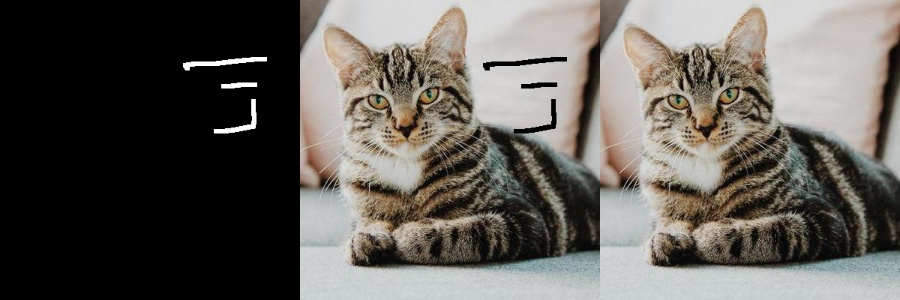

In [ ]:
mask_cat = cv.imread(img_cat_mask_path)
original_cat = cv.imread(cat_path)
inpaint_cat = inpaint_image(cat_path, img_cat_mask_path)

height = 300
mask_cat_resized = cv.resize(mask_cat, (int(mask_cat.shape[1] * height / mask_cat.shape[0]), height))
original_cat_resized = cv.resize(original_cat, (int(original_cat.shape[1] * height / original_cat.shape[0]), height))
inpaint_cat_resized = cv.resize(inpaint_cat, (int(inpaint_cat.shape[1] * height / inpaint_cat.shape[0]), height))

combined_image = np.hstack((mask_cat_resized, original_cat_resized, inpaint_cat_resized))

cv2_imshow(combined_image)

## 2. Reuse the Caucasian image provided for the problem. Determine the coordinates of the two regions that require a mask on the image (x_start, x_end, y_start, y_end).

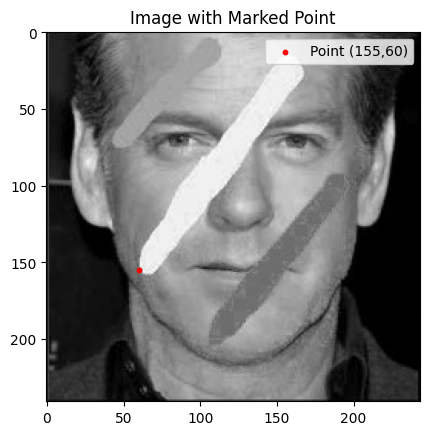

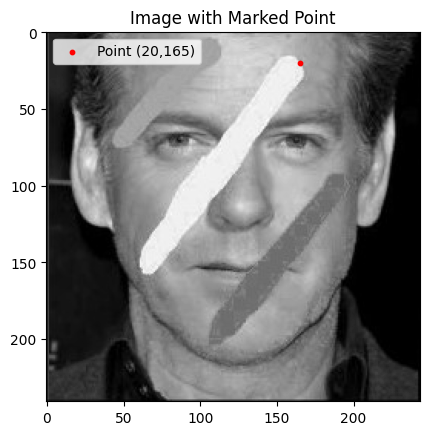

In [ ]:
mark_point_on_image(caucasian_path, 155, 60)
mark_point_on_image(caucasian_path, 20, 165)

## 3. **Estimate the frequency range** of the two regions identified in step 2 to restore the image.

In [ ]:
intensities = []
for j in range(64, 82):
    intensity = get_pixel_intensity(caucasian_path, 140, j)
    print(f"Intensity at (140,{j}): {intensity}")
    intensities.append(intensity)

min_intensity = min(intensities)
max_intensity = max(intensities)
print(f"\nMinimum intensity in range: {min_intensity}")
print(f"Maximum intensity in range: {max_intensity}")

Intensity at (140,64): 234
Intensity at (140,65): 226
Intensity at (140,66): 229
Intensity at (140,67): 224
Intensity at (140,68): 228
Intensity at (140,69): 222
Intensity at (140,70): 222
Intensity at (140,71): 236
Intensity at (140,72): 232
Intensity at (140,73): 229
Intensity at (140,74): 228
Intensity at (140,75): 230
Intensity at (140,76): 231
Intensity at (140,77): 230
Intensity at (140,78): 230
Intensity at (140,79): 231
Intensity at (140,80): 226
Intensity at (140,81): 229

Minimum intensity in range: 222
Maximum intensity in range: 236


## 4. **Create a mask** based on the regions and frequency ranges identified in steps 2 and 3.  

(241, 244)


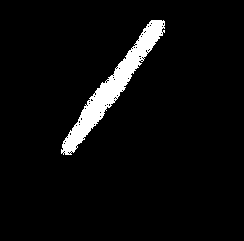

In [ ]:
mask_caucasian = threshold_image(img, 222, 236,(60,20,165,155))
print(mask_caucasian.shape)
mask_caucasian_show = cv2_imshow(mask_caucasian)


## 5. Run the image again using the masks created in step 4.

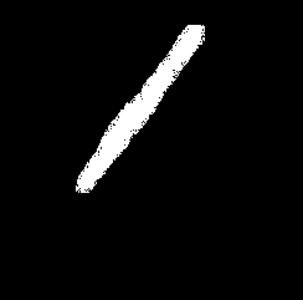

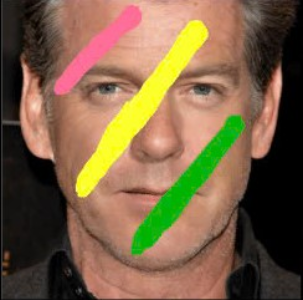

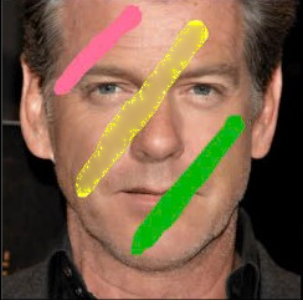

In [ ]:
inpaint_caucasian = inpaint1_image(caucasian_path, mask_caucasian,inpaint_radius=100, inpaint_method=cv.INPAINT_TELEA)
height = 300
original_caucasian = cv.imread(caucasian_path)
# Resize the images
mask_caucasian_resized = cv.resize(mask_caucasian, (int(mask_caucasian.shape[1] * height / mask_caucasian.shape[0]), height))
original_caucasian_resized = cv.resize(original_caucasian, (int(original_caucasian.shape[1] * height / original_caucasian.shape[0]), height))
inpaint_caucasian_resized = cv.resize(inpaint_caucasian, (int(inpaint_caucasian.shape[1] * height / inpaint_caucasian.shape[0]), height))



cv2_imshow(mask_caucasian_resized)
cv2_imshow(original_caucasian_resized)
cv2_imshow(inpaint_caucasian_resized)


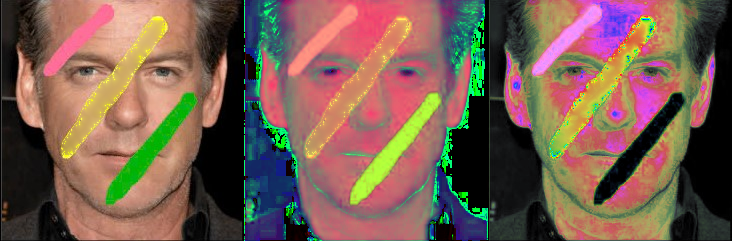

In [ ]:
# Convert RGB to HSV
hsv_image = cv.cvtColor(inpaint_caucasian, cv.COLOR_RGB2HSV)
# Convert HSV back to RGB
rgb_image = cv.cvtColor(inpaint_caucasian, cv.COLOR_HSV2RGB)

height, width = 300, 300

font = cv.FONT_HERSHEY_SIMPLEX
font_scale = 1
font_color = (0, 255, 0)
thickness = 2

combined_image = np.hstack((inpaint_caucasian,hsv_image, rgb_image))

cv2_imshow(combined_image)

## Tạo mask tứ giác để inpaint

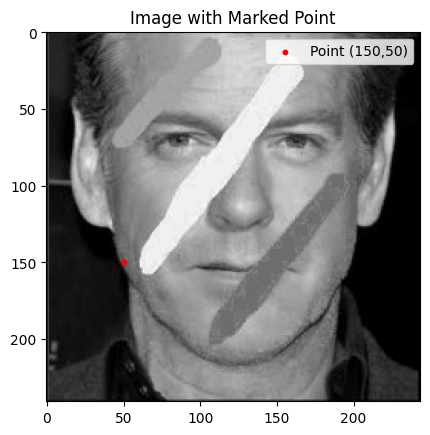

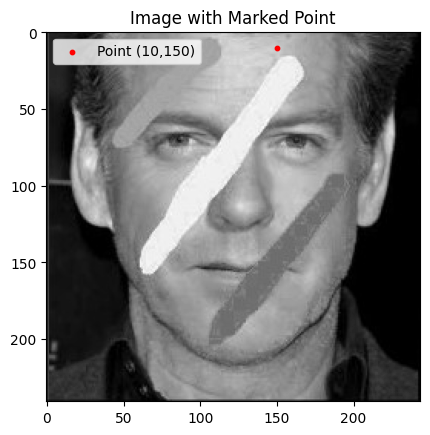

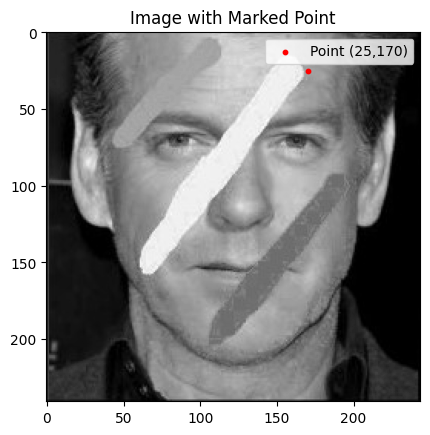

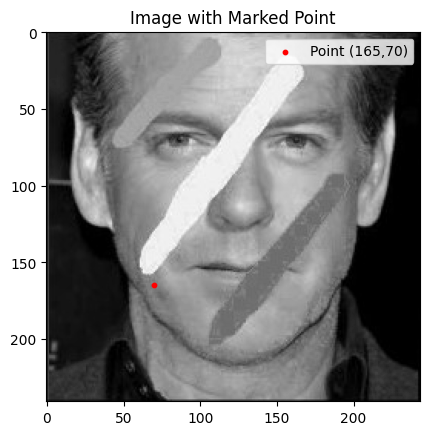

In [ ]:
mark_point_on_image(caucasian_path, 150, 50)
mark_point_on_image(caucasian_path, 10, 150)
mark_point_on_image(caucasian_path, 25, 170)
mark_point_on_image(caucasian_path, 165, 70)


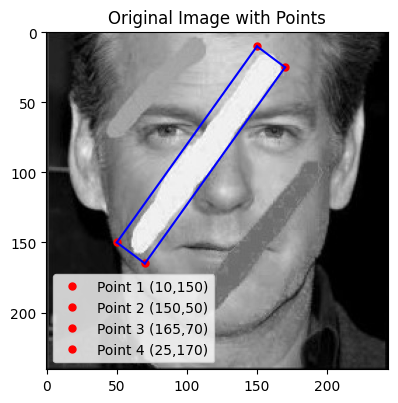

In [ ]:
points = np.array([
    [10, 150],
    [150, 50],
    [165, 70],
    [25, 170]
])

img = cv.imread(caucasian_path, cv.IMREAD_GRAYSCALE)
mask = np.zeros_like(img)

pts = points.reshape((-1, 1, 2))
cv.fillPoly(mask, [pts], color=255)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
for i, (y, x) in enumerate(points):
    plt.plot(x, y, 'r.', markersize=10, label=f'Point {i+1} ({y},{x})')
plt.plot([points[-1,1], points[0,1]], [points[-1,0], points[0,0]], 'b-')
for i in range(len(points)-1):
    plt.plot([points[i,1], points[i+1,1]], [points[i,0], points[i+1,0]], 'b-')
plt.title('Original Image with Points')
plt.legend()


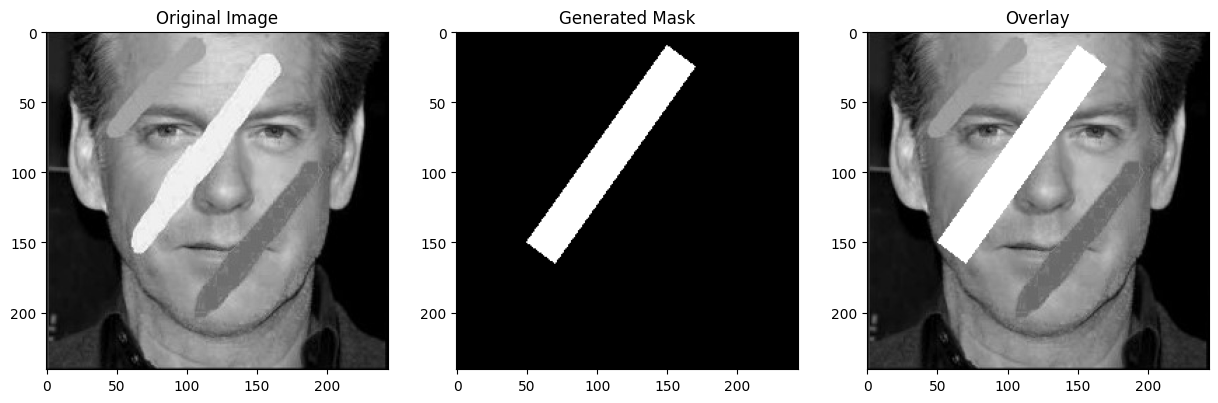

In [ ]:
img = cv.imread(caucasian_path, cv.IMREAD_GRAYSCALE)

mask_caucasian = np.zeros_like(img)
points = np.array([
    [150, 10],
    [50, 150],
    [70, 165],
    [170, 25]
])

pts = points.reshape((-1, 1, 2))
cv.fillPoly(mask_caucasian, [pts], color=255)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')

plt.subplot(1, 3, 2)
plt.imshow(mask_caucasian, cmap='gray')
plt.title('Generated Mask')

plt.subplot(1, 3, 3)
overlay = img.copy()
overlay[mask_caucasian > 0] = 255
plt.imshow(overlay, cmap='gray')
plt.title('Overlay')

plt.show()

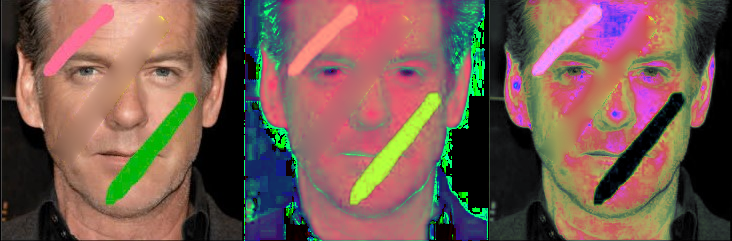

In [ ]:
# Convert RGB to HSV
hsv_image = cv.cvtColor(inpaint_caucasian, cv.COLOR_RGB2HSV)
# Convert HSV back to RGB
rgb_image = cv.cvtColor(inpaint_caucasian, cv.COLOR_HSV2RGB)

height, width = 300, 300

font = cv.FONT_HERSHEY_SIMPLEX
font_scale = 1
font_color = (0, 255, 0)
thickness = 2

combined_image = np.hstack((inpaint_caucasian,hsv_image, rgb_image))

cv2_imshow(combined_image)

## Inpaint đường gạch cuối

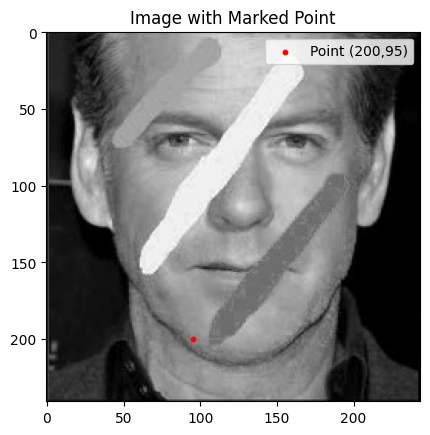

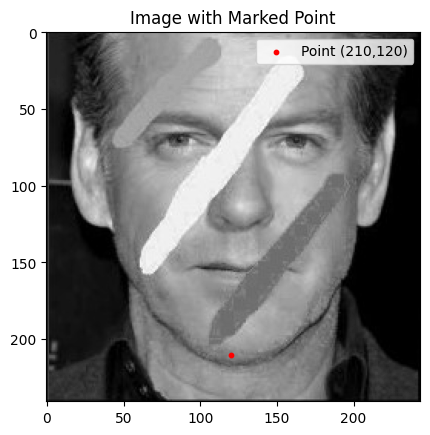

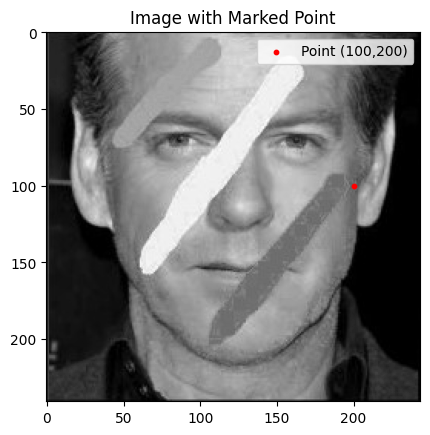

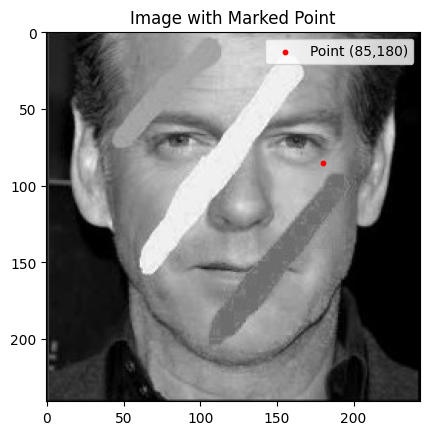

In [ ]:
mark_point_on_image(caucasian_path, 200, 95)
mark_point_on_image(caucasian_path, 210, 120)
mark_point_on_image(caucasian_path, 100, 200)
mark_point_on_image(caucasian_path, 85, 180)


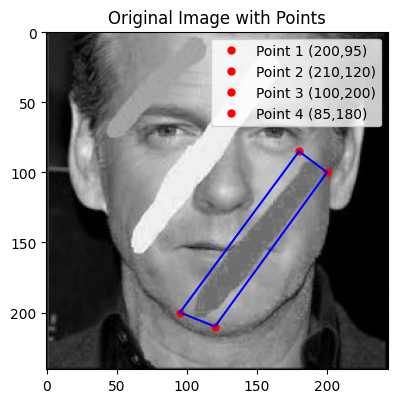

In [ ]:
points = np.array([
    [200, 95],
    [210, 120],
    [100, 200],
    [85, 180]
])

img = cv.imread(caucasian_path, cv.IMREAD_GRAYSCALE)
mask = np.zeros_like(img)

pts = points.reshape((-1, 1, 2))
cv.fillPoly(mask, [pts], color=255)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
for i, (y, x) in enumerate(points):
    plt.plot(x, y, 'r.', markersize=10, label=f'Point {i+1} ({y},{x})')
plt.plot([points[-1,1], points[0,1]], [points[-1,0], points[0,0]], 'b-')
for i in range(len(points)-1):
    plt.plot([points[i,1], points[i+1,1]], [points[i,0], points[i+1,0]], 'b-')
plt.title('Original Image with Points')
plt.legend()


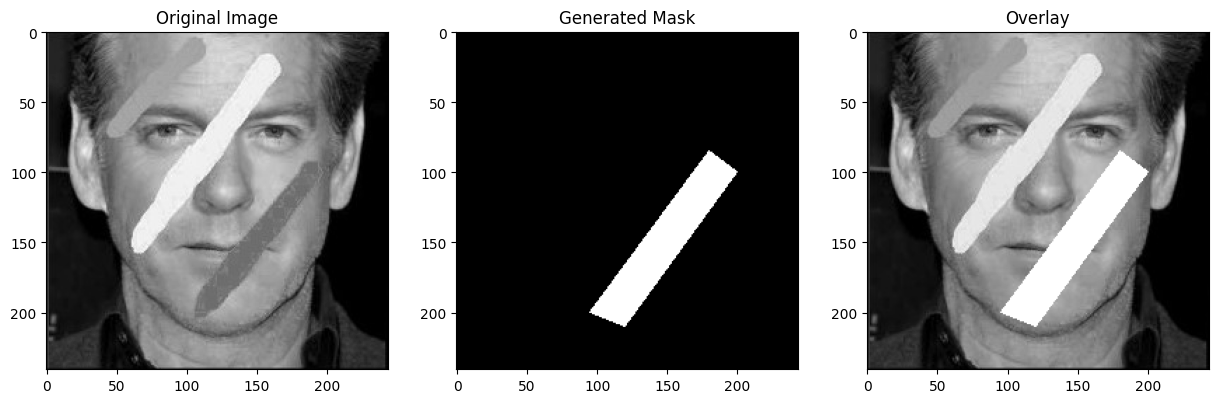

In [ ]:
img = cv.imread(caucasian_path, cv.IMREAD_GRAYSCALE)

mask_caucasian = np.zeros_like(img)
points = np.array([
    [95, 200],
    [120, 210],
    [200, 100],
    [180, 85]
])

# Vẽ tứ giác trên mask
pts = points.reshape((-1, 1, 2))
cv.fillPoly(mask_caucasian, [pts], color=255)

# Hiển thị kết quả
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')

plt.subplot(1, 3, 2)
plt.imshow(mask_caucasian, cmap='gray')
plt.title('Generated Mask')

plt.subplot(1, 3, 3)
overlay = img.copy()
overlay[mask_caucasian > 0] = 255
plt.imshow(overlay, cmap='gray')
plt.title('Overlay')

plt.show()

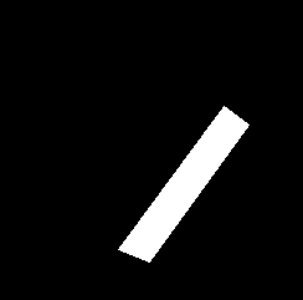

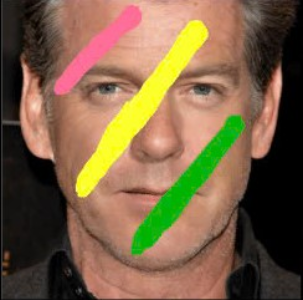

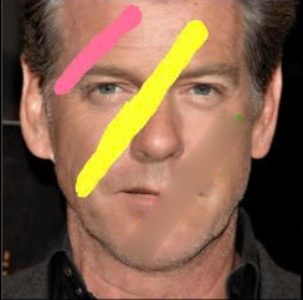

In [ ]:

inpaint_caucasian = inpaint1_image(caucasian_path, mask_caucasian, inpaint_radius=100, inpaint_method=cv.INPAINT_TELEA)

height = 300
original_caucasian = cv.imread(caucasian_path)

mask_caucasian_resized = cv.resize(mask_caucasian, (int(mask_caucasian.shape[1] * height / mask_caucasian.shape[0]), height))
original_caucasian_resized = cv.resize(original_caucasian, (int(original_caucasian.shape[1] * height / original_caucasian.shape[0]), height))
inpaint_caucasian_resized = cv.resize(inpaint_caucasian, (int(inpaint_caucasian.shape[1] * height / inpaint_caucasian.shape[0]), height))

cv2_imshow(mask_caucasian_resized)
cv2_imshow(original_caucasian_resized)
cv2_imshow(inpaint_caucasian_resized)

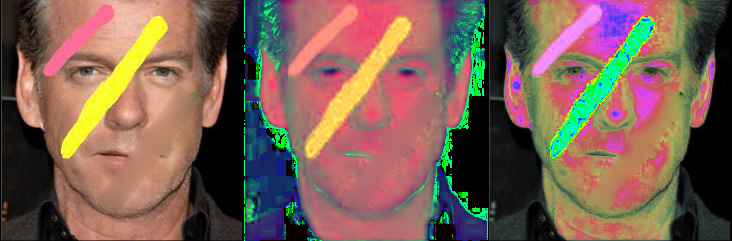

In [ ]:
# Convert RGB to HSV
hsv_image = cv.cvtColor(inpaint_caucasian, cv.COLOR_RGB2HSV)
# Convert HSV back to RGB
rgb_image = cv.cvtColor(inpaint_caucasian, cv.COLOR_HSV2RGB)

height, width = 300, 300

font = cv.FONT_HERSHEY_SIMPLEX
font_scale = 1
font_color = (0, 255, 0)
thickness = 2

combined_image = np.hstack((inpaint_caucasian,hsv_image, rgb_image))

cv2_imshow(combined_image)

## 6. **Choose two vectors, two matrices, and two 3D tensors with larger sizes.** Perform all calculations as instructed in the sample essay.  

In [ ]:
# Set random seed for reproducibility
gen = torch.Generator().manual_seed(2147483647)

print("VECTOR OPERATIONS:")
v1 = torch.randint(0, 100, (100,), generator=gen)
v2 = torch.randint(0, 100, (100,), generator=gen)

print("Vector 1:", v1)
print("Vector 2:", v2)
print("\nVector Addition:", v1 + v2)
print("Vector Subtraction:", v1 - v2)
print("Dot Product:", torch.dot(v1, v2))
print("Hadamard Product:", v1 * v2)
print("Vector Scalar Multiplication (k=3):", 3 * v1)

print("\nMATRIX OPERATIONS:")
m1 = torch.randint(0, 100, (5, 5), generator=gen)
m2 = torch.randint(0, 100, (5, 5), generator=gen)

print("Matrix 1:\n", m1)
print("\nMatrix 2:\n", m2)
print("\nMatrix Addition:\n", m1 + m2)
print("\nMatrix Subtraction:\n", m1 - m2)
print("\nMatrix Multiplication:\n", torch.matmul(m1, m2))
print("\nHadamard Product:\n", m1 * m2)
print("\nMatrix Scalar Multiplication (k=3):\n", 3 * m1)

print("\nTENSOR OPERATIONS:")
t1 = torch.randint(0, 100, (4, 4, 4), generator=gen)
t2 = torch.randint(0, 100, (4, 4, 4), generator=gen)

print("Tensor 1:\n", t1)
print("\nTensor 2:\n", t2)
print("\nTensor Addition:\n", t1 + t2)
print("\nTensor Subtraction:\n", t1 - t2)
print("\nTensor Matrix Multiplication:\n", torch.matmul(t1, t2.transpose(1,2)))
print("\nHadamard Product:\n", t1 * t2)
print("\nTensor Scalar Multiplication (k=3):\n", 3 * t1)

VECTOR OPERATIONS:
Vector 1: tensor([31, 94, 49, 72, 53, 80, 84, 16, 47,  7, 61, 75, 76, 98, 31,  4, 24, 19,
        98, 80, 73,  6, 96, 50, 19, 81, 10, 30, 22, 92, 57, 11, 98, 21, 69, 30,
        96, 13, 46, 94,  5, 27, 93, 37, 42, 70, 15, 31, 80,  4, 60, 18, 80, 86,
         0, 95, 68, 26, 91, 70, 55, 61, 11, 96, 31, 22, 86, 90,  2,  6, 61, 65,
        73, 81, 94, 25, 22, 43, 44,  6, 40, 54, 77, 35, 95, 84, 77, 87,  1,  6,
        56, 16, 18, 10, 12,  5,  3, 64, 89, 61])
Vector 2: tensor([71, 62, 99, 23, 37,  2, 83, 53, 21, 32, 48, 91, 67, 67, 47, 90, 65, 80,
        94, 93, 12, 16,  9, 25, 90, 51, 75, 23, 14, 25, 69, 46, 34, 53, 71, 28,
        15, 50, 57, 55, 53, 30, 92, 97, 14, 29, 97,  9, 26, 26, 81, 91,  5,  7,
        11, 47, 50, 40, 81, 30, 44, 45, 37, 68, 74, 69, 36, 37, 17,  9, 80, 39,
        19,  5, 31, 44, 46, 51,  6, 64, 62, 69, 78, 75, 95, 44, 39, 75, 42, 41,
        34, 36, 70, 73, 23, 94, 83, 53, 89, 77])

Vector Addition: tensor([102, 156, 148,  95,  90,  82, 167,  6